# Feature Engineering · Model Zoo · Subgroup Audit · Stratified Validation


Implements the leakage-safe pipeline described in the README:
- In-pipeline feature engineering (`bmi^2`, `age×bmi`, `smoker×bmi`)
- `ColumnTransformer` encoding/standardization
- Model zoo with small-grid CV (Linear / Ridge / ElasticNet / GBRT)
- Subgroup audit (smoker / region)
- Figures: residuals & learning curve


In [1]:
# ==== Imports & paths ====
import os, json, math, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

PROJ_DIR   = os.getcwd()
DATA_PATH  = os.path.join(PROJ_DIR, "data", "insurance.csv")
REPORTS_DIR= os.path.join(PROJ_DIR, "reports")
FIG_DIR    = os.path.join(REPORTS_DIR, "figures")
MODELS_DIR = os.path.join(PROJ_DIR, "models")

for d in [REPORTS_DIR, FIG_DIR, MODELS_DIR]:
    pathlib.Path(d).mkdir(parents=True, exist_ok=True)


In [2]:
# ==== Schema & data ====
CATEGORICAL = ["sex", "smoker", "region"]
NUMERIC     = ["age", "bmi", "children"]
TARGET      = "charges"

df = pd.read_csv(DATA_PATH)
X = df[CATEGORICAL + NUMERIC].copy()
y = df[TARGET].copy()

# ==== Feature engineering (no feature_names_out; allow new columns) ====
NEW_NUMERIC = ["bmi2", "age_bmi", "smoker_bmi"]

def add_interactions(Xd: pd.DataFrame):
    Xd = Xd.copy()
    Xd["bmi2"]       = Xd["bmi"] ** 2
    Xd["age_bmi"]    = Xd["age"] * Xd["bmi"]
    smoker_num       = (Xd["smoker"] == "yes").astype(int)
    Xd["smoker_bmi"] = Xd["bmi"] * smoker_num
    return Xd

feat_eng = FunctionTransformer(add_interactions, validate=False)
all_numeric = NUMERIC + NEW_NUMERIC

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), all_numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
    ]
)

In [3]:
# ==== Split ====
# Create a temporary category for stratification (Low, Medium, High charges)
df["charges_cat"] = pd.qcut(df["charges"], q=5, labels=False)

X = df[CATEGORICAL + NUMERIC].copy()
y = df[TARGET].copy()

# Stratify based on the charge categories
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=df["charges_cat"] # <--- THIS MAKES IT STRATIFIED
)

# Clean up the temporary column so it doesn't leak into the model
del df["charges_cat"]

# ==== Metrics (RMSE compatible with older sklearn) ====
def evaluate(y_true, y_pred):
    try:
        from sklearn.metrics import root_mean_squared_error
        rmse = float(root_mean_squared_error(y_true, y_pred))
    except Exception:
        rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return {
        "r2":  float(r2_score(y_true, y_pred)),
        "rmse": rmse,
        "mae": float(mean_absolute_error(y_true, y_pred)),
    }

# ==== Model zoo & CV ====
def build_model(name: str):
    if name == "linear":
        model = LinearRegression(); grid = {}
    elif name == "ridge":
        model = Ridge(random_state=42); grid = {"model__alpha": [0.1, 1.0, 10.0, 50.0]}
    elif name == "elasticnet":
        model = ElasticNet(random_state=42, max_iter=5000)
        grid = {"model__alpha": [0.001, 0.01, 0.1, 1.0], "model__l1_ratio": [0.2, 0.5, 0.8]}
    elif name == "gbrt":
        model = GradientBoostingRegressor(random_state=42)
        grid = {"model__n_estimators": [200], "model__learning_rate": [0.05, 0.1], "model__max_depth": [2, 3], "model__subsample": [0.9, 1.0]}
    else:
        raise ValueError(name)
    pipe = Pipeline([("feat", feat_eng), ("pre", preprocess), ("model", model)])
    return pipe, grid


In [4]:
models = ["linear", "ridge", "elasticnet", "gbrt"]
cv = KFold(n_splits=3, shuffle=True, random_state=42)

all_metrics = {}
best = {"name": None, "rmse": float("inf"), "estimator": None, "best_params": {}}

for name in models:
    pipe, grid = build_model(name)
    if grid:
        gs = GridSearchCV(pipe, grid, cv=cv, n_jobs=1, error_score="raise")
        gs.fit(X_train, y_train)
        est = gs.best_estimator_; params = gs.best_params_
    else:
        pipe.fit(X_train, y_train)
        est = pipe; params = {}
    pred = est.predict(X_test)
    m = evaluate(y_test, pred)
    all_metrics[name] = {"metrics": m, "best_params": params}
    if m["rmse"] < best["rmse"]:
        best = {"name": name, "rmse": m["rmse"], "estimator": est, "best_params": params}

print("Best model:", best["name"], best["best_params"])

Best model: gbrt {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 200, 'model__subsample': 0.9}


In [5]:
# ==== Save artifacts (robust JSON & picklable model) ====
def to_serializable(obj):
    if isinstance(obj, (np.floating, np.integer)): return obj.item()
    if isinstance(obj, (np.ndarray,)):            return obj.tolist()
    if isinstance(obj, float) and (math.isnan(obj) or math.isinf(obj)): return None
    return obj
def map_json(o):
    if isinstance(o, dict): return {k: map_json(v) for k, v in o.items()}
    if isinstance(o, list): return [map_json(v) for v in o]
    return to_serializable(o)

model_path = os.path.join(MODELS_DIR, f"best_{best['name']}.pkl")
joblib.dump(best["estimator"], model_path)

payload = map_json({"per_model": all_metrics, "best_model": best["name"], "best_params": best["best_params"]})
with open(os.path.join(REPORTS_DIR, "metrics_enhanced.json"), "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)

In [6]:
# ==== Subgroup audit ====
def subgroup_errors(estimator, X_test, y_test, group):
    df_eval = X_test.copy()
    df_eval["__y_true__"] = y_test.values
    df_eval["__y_pred__"] = estimator.predict(X_test)
    res = {}
    for g, sub in df_eval.groupby(group):
        rmse = float(np.sqrt(mean_squared_error(sub["__y_true__"], sub["__y_pred__"])))
        mae  = float(mean_absolute_error(sub["__y_true__"], sub["__y_pred__"]))
        res[str(g)] = {"rmse": rmse, "mae": mae, "n": int(len(sub))}
    return res

subgroups = {
    "smoker": subgroup_errors(best["estimator"], X_test, y_test, "smoker"),
    "region": subgroup_errors(best["estimator"], X_test, y_test, "region"),
}
with open(os.path.join(REPORTS_DIR, "subgroup_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(subgroups, f, indent=2, ensure_ascii=False)

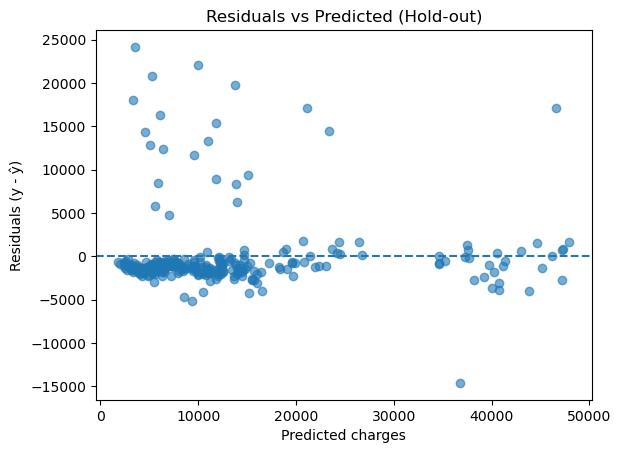

In [7]:
# ==== Figures ====
# 1) Residuals vs Predicted
yhat = best["estimator"].predict(X_test)
resid = y_test - yhat
plt.figure(); plt.scatter(yhat, resid, alpha=0.6); plt.axhline(0, linestyle="--")
plt.xlabel("Predicted charges"); plt.ylabel("Residuals (y - ŷ)")
plt.title("Residuals vs Predicted (Hold-out)")
plt.savefig(os.path.join(FIG_DIR, "residuals_vs_pred.png"), bbox_inches="tight")


Saved: /Users/cedar/Documents/Job Aplication/Projects/insurance-pricing_new/models/best_gbrt.pkl
Done.


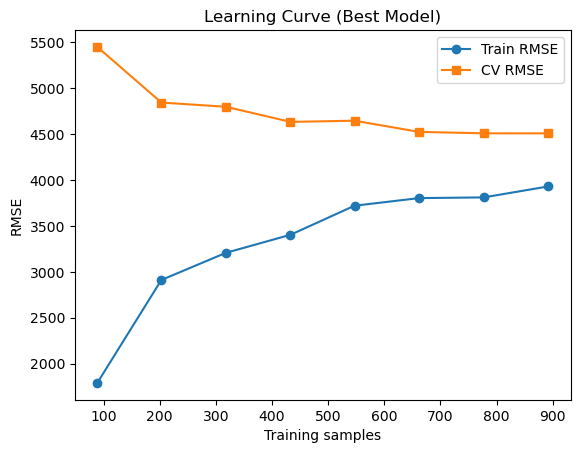

In [8]:
# 2) Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    best["estimator"], X, y, cv=3, scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=1, shuffle=True, random_state=42
)
mean_train_rmse = np.sqrt(-train_scores).mean(axis=1)
mean_val_rmse   = np.sqrt(-val_scores).mean(axis=1)

plt.figure()
plt.plot(train_sizes, mean_train_rmse, marker="o", label="Train RMSE")
plt.plot(train_sizes, mean_val_rmse, marker="s", label="CV RMSE")
plt.xlabel("Training samples"); plt.ylabel("RMSE"); plt.legend()
plt.title("Learning Curve (Best Model)")
plt.savefig(os.path.join(FIG_DIR, "learning_curve.png"), bbox_inches="tight")

print("Saved:", model_path)
print("Done.")